In [1]:

!apt-get install -y fonts-nanum*
!rm -rf /root/.cache/matplotlib/* # 폰트 캐시 재설정

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# Nanum 글꼴 설치
!apt-get -y install fonts-nanum

# matplotlib에서 한글 폰트 사용 설정
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc

# 나눔 글꼴 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_manager.fontManager.addfont(font_path)
rc('font', family='NanumGothic')

import matplotlib.font_manager as fm
!apt-get -qq install fonts-nanum

fe = fm.FontEntry(
    fname=r'/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
    name='NanumGothic')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams.update({'font.size': 10, 'font.family': 'NanumGothic'}) # 폰트 설정

import matplotlib.pyplot as plt
from matplotlib import font_manager

# 글꼴 경로 추가
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_manager.fontManager.addfont(font_path)

# 한글을 사용할 수 있도록 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'fonts-nanum-extra' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum-coding' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum-eco' for glob 'fonts-nanum*'
Note, selecting 'fonts-nanum' for glob 'fonts-nanum*'
The following NEW packages will be installed:
  fonts-nanum fonts-nanum-coding fonts-nanum-eco fonts-nanum-extra
0 upgraded, 4 newly installed, 0 to remove and 2 not upgraded.
Need to get 46.0 MB of archives.
After this operation, 177 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-coding all 2.5-3 [4,988 B]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-eco all 1.000-7 [14.7 MB]
Get:4 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-extra all 20200506-1 [21.0 

In [2]:
import requests
from google.colab import drive

# 1. 구글 드라이브 마운트 (연결)
# 코드를 처음 실행하면 구글 계정 권한 허용 창이 뜹니다. 허용해 주세요!
drive.mount('/content/drive')

Mounted at /content/drive


🔄 1단계: 3개의 데이터를 불러오고 병합합니다...
✅ 병합 완료! 총 720개의 유효한 공통 격자 데이터를 확보했습니다.

📊 2단계: 3개 지표 간의 피어슨 상관계수를 계산하고 시각화합니다...


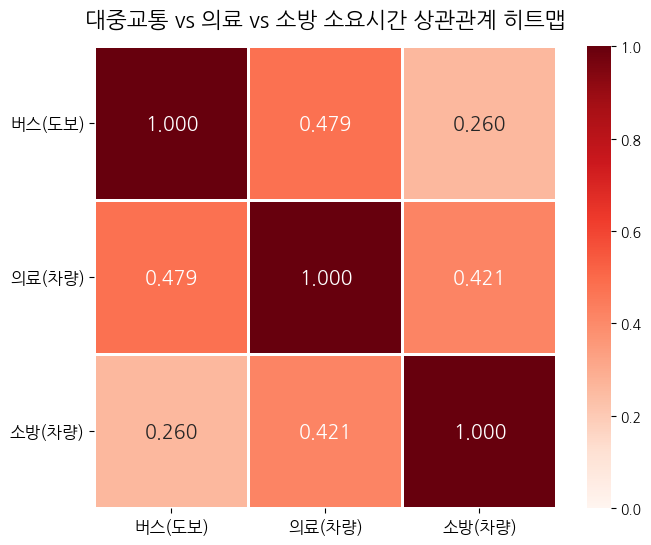


⚖️ 3단계: 상위 5% 극단치를 제어(Capping)한 후 Min-Max 정규화를 수행합니다...


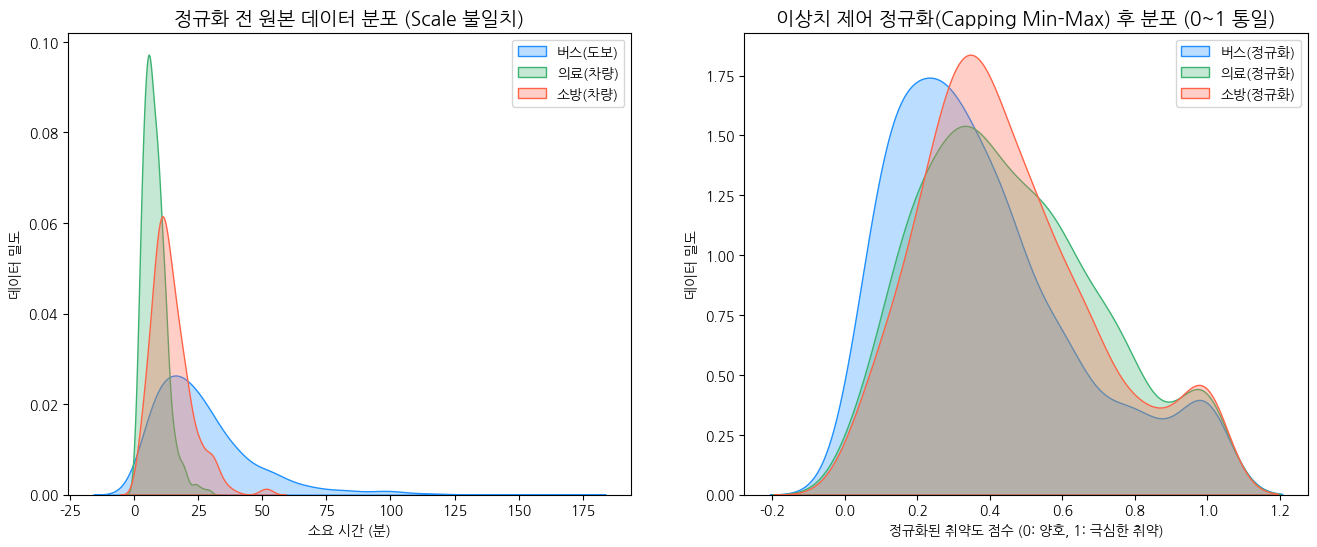

,grid_id,time_bus_walk,norm_bus,time_med_drive,norm_med,time_fire_drive,norm_fire
0,마마2271,28.1,0.423886,5.92,0.346245,8.516667,0.260666
1,마마2272,12.5,0.182550,3.72,0.204921,7.516667,0.226443
2,마마2273,9.4,0.134592,9.58,0.581358,6.933333,0.206480
3,마마2374,24.6,0.369740,5.88,0.343676,9.533333,0.295460
4,마마2375,27.6,0.416151,5.20,0.299994,9.950000,0.309719


In [3]:
# ==============================================================
# 🎨 [0/4] 라이브러리 로드 및 한글 폰트 설정
# ==============================================================
!apt-get -qq -y install fonts-nanum > /dev/null

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os
import warnings

warnings.filterwarnings('ignore')

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# ==============================================================
# 🚨 [1/4] 데이터 로드 및 Key 통일 병합 (Inner Join)
# ==============================================================
BASE_DIR = '/content/drive/MyDrive/영천의미학/'

print("🔄 1단계: 3개의 데이터를 불러오고 병합합니다...")

# 1. 버스 데이터 (가장 최근에 만든 최종 Smoothed 파일 기준)
df_bus = pd.read_csv(BASE_DIR + 'FINAL_bus_accessibility_master_Smoothed.csv', encoding='utf-8-sig')
df_bus['grid_id'] = df_bus['grid_id'].astype(str).str.strip()

# 2. 의료 데이터
df_med = pd.read_csv(BASE_DIR + 'step5_final_smoothed_result_fix.csv', encoding='utf-8-sig')
df_med['격자코드'] = df_med['격자코드'].astype(str).str.strip()

# 3. 소방 데이터
df_fire = pd.read_csv(BASE_DIR + 'fire_final.csv', encoding='utf-8-sig')
df_fire['Grid_Name'] = df_fire['Grid_Name'].astype(str).str.strip()

# 🌟 Inner Join으로 3개 데이터가 모두 존재하는 순수 격자만 추출
df_merged = df_bus[['grid_id', 'elderly_walk_time_min']].merge(
    df_med[['격자코드', '최종_이동시간_분']], left_on='grid_id', right_on='격자코드', how='inner'
).merge(
    df_fire[['Grid_Name', 'best_fire_final_duration_min']], left_on='grid_id', right_on='Grid_Name', how='inner'
)

# 컬럼명 직관적으로 변경
df_merged = df_merged.rename(columns={
    'elderly_walk_time_min': 'time_bus_walk',
    '최종_이동시간_분': 'time_med_drive',
    'best_fire_final_duration_min': 'time_fire_drive'
})

print(f"✅ 병합 완료! 총 {len(df_merged)}개의 유효한 공통 격자 데이터를 확보했습니다.")

# ==============================================================
# 📊 [2/4] 상관관계 분석 및 히트맵 시각화
# ==============================================================
print("\n📊 2단계: 3개 지표 간의 피어슨 상관계수를 계산하고 시각화합니다...")

# 상관계수 계산
corr_matrix = df_merged[['time_bus_walk', 'time_med_drive', 'time_fire_drive']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap='Reds', vmin=0, vmax=1,
            linewidths=1, square=True, annot_kws={"size": 14, "weight": "bold"})

plt.title("대중교통 vs 의료 vs 소방 소요시간 상관관계 히트맵", fontsize=16, fontweight='bold', pad=15)
plt.xticks(ticks=[0.5, 1.5, 2.5], labels=['버스(도보)', '의료(차량)', '소방(차량)'], fontsize=12)
plt.yticks(ticks=[0.5, 1.5, 2.5], labels=['버스(도보)', '의료(차량)', '소방(차량)'], fontsize=12, rotation=0)

heatmap_path = BASE_DIR + 'correlation_heatmap.png'
plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================
# ⚖️ [3/4] 이상치 제어 기반 정규화 (Capping Min-Max Scaling)
# ==============================================================
print("\n⚖️ 3단계: 상위 5% 극단치를 제어(Capping)한 후 Min-Max 정규화를 수행합니다...")

def cap_and_normalize(series, cap_percentile=0.95):
    """상위 cap_percentile(예: 95%) 값으로 튀는 값을 누른 뒤 0~1 정규화"""
    # 1. 상위 n% 임계값 계산
    cap_value = series.quantile(cap_percentile)

    # 2. 임계값 초과 데이터는 임계값으로 깎아내기 (Capping)
    capped_series = np.clip(series, series.min(), cap_value)

    # 3. Min-Max 정규화 (0 ~ 1 범위)
    normalized_series = (capped_series - capped_series.min()) / (capped_series.max() - capped_series.min())
    return normalized_series

# 3개 지표에 정규화 적용 (상위 5% 캡핑)
df_merged['norm_bus'] = cap_and_normalize(df_merged['time_bus_walk'], 0.95)
df_merged['norm_med'] = cap_and_normalize(df_merged['time_med_drive'], 0.95)
df_merged['norm_fire'] = cap_and_normalize(df_merged['time_fire_drive'], 0.95)

# ==============================================================
# 📈 [4/4] 정규화 결과 시각화 (KDE 밀도 추정 그래프)
# ==============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# [왼쪽] 정규화 전 원본 데이터 분포 (스케일 제각각)
sns.kdeplot(df_merged['time_bus_walk'], ax=axes[0], label='버스(도보)', color='dodgerblue', fill=True, alpha=0.3)
sns.kdeplot(df_merged['time_med_drive'], ax=axes[0], label='의료(차량)', color='mediumseagreen', fill=True, alpha=0.3)
sns.kdeplot(df_merged['time_fire_drive'], ax=axes[0], label='소방(차량)', color='tomato', fill=True, alpha=0.3)
axes[0].set_title("정규화 전 원본 데이터 분포 (Scale 불일치)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("소요 시간 (분)")
axes[0].set_ylabel("데이터 밀도")
axes[0].legend()

# [오른쪽] 이상치 제어 + 정규화 후 데이터 분포 (0~1 통일)
sns.kdeplot(df_merged['norm_bus'], ax=axes[1], label='버스(정규화)', color='dodgerblue', fill=True, alpha=0.3)
sns.kdeplot(df_merged['norm_med'], ax=axes[1], label='의료(정규화)', color='mediumseagreen', fill=True, alpha=0.3)
sns.kdeplot(df_merged['norm_fire'], ax=axes[1], label='소방(정규화)', color='tomato', fill=True, alpha=0.3)
axes[1].set_title("이상치 제어 정규화(Capping Min-Max) 후 분포 (0~1 통일)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("정규화된 취약도 점수 (0: 양호, 1: 극심한 취약)")
axes[1].set_ylabel("데이터 밀도")
axes[1].legend()

norm_plot_path = BASE_DIR + 'normalization_distribution.png'
plt.savefig(norm_plot_path, dpi=300, bbox_inches='tight')
plt.show()

# 데이터프레임 상태 확인
display(df_merged[['grid_id', 'time_bus_walk', 'norm_bus', 'time_med_drive', 'norm_med', 'time_fire_drive', 'norm_fire']].head())

🧠 1단계: 정보이론에 기반한 엔트로피 가중치를 계산합니다...

⚖️ [엔트로피 알고리즘 기반 최종 가중치 산출 결과]
▶ 버스(도보) 가중치 : 41.85 %
▶ 의료(차량) 가중치 : 29.94 %
▶ 소방(차량) 가중치 : 28.21 %

🏆 2단계: 가중치를 적용하여 최종 통합 위치 데이터를 생성합니다...
📁 완벽하게 융합된 최종 위치 데이터가 저장되었습니다: /content/drive/MyDrive/영천의미학/FINAL_LOCATION_VULNERABILITY_INDEX.csv


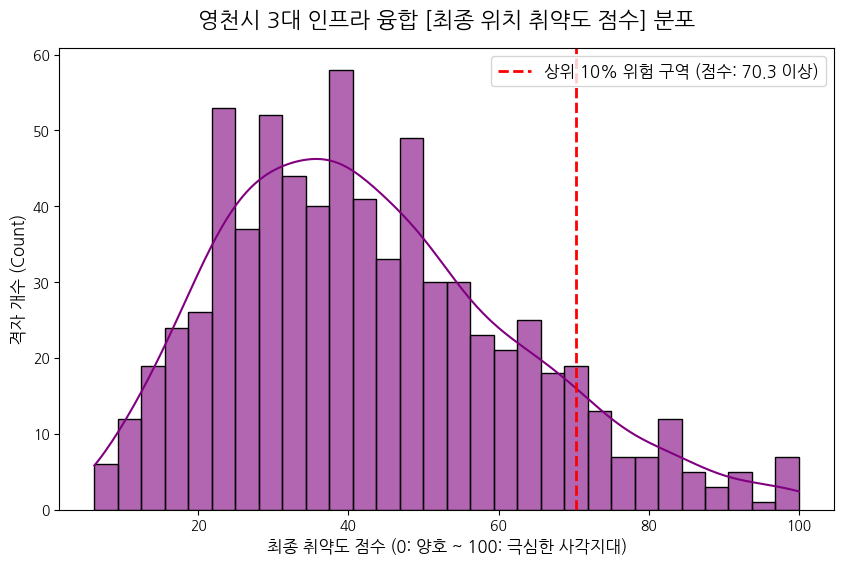

,grid_id,final_location_score_100
434,마마1989,100.00
180,마마3260,100.00
423,마마2089,99.69
165,마마3460,99.69
8,마마4570,99.47
482,마마1390,98.76
487,마마2295,96.91
478,마마1489,95.25
164,마마3360,93.71
183,마마3261,93.43


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==============================================================
# 🧠 [1/4] 엔트로피(Entropy) 가중치 산출 알고리즘
# ==============================================================
print("🧠 1단계: 정보이론에 기반한 엔트로피 가중치를 계산합니다...")

# 정규화된 3개 지표만 추출
indicators = ['norm_bus', 'norm_med', 'norm_fire']
X = df_merged[indicators].copy()

# [중요 방어 로직] 데이터에 0이 있으면 log(0) 에러가 발생하므로, 아주 작은 수(epsilon)를 더해줍니다.
epsilon = 1e-8
X_safe = X + epsilon

# 1. 지표별 비율(P_ij) 계산 (해당 격자의 점수가 전체 합에서 차지하는 비율)
P = X_safe / X_safe.sum(axis=0)

# 2. 엔트로피(E_j) 계산
n = len(df_merged)  # 전체 격자 수 (n)
k = 1.0 / np.log(n) # 상용 상수
E = -k * (P * np.log(P)).sum(axis=0)

# 3. 정보 유용성(d_j) 계산 (엔트로피의 역개념, 분산이 클수록 d_j가 커짐)
d = 1.0 - E

# 4. 최종 가중치(W_j) 도출 (전체 합이 1이 되도록 비율 계산)
weights = d / d.sum()

print("\n========================================")
print("⚖️ [엔트로피 알고리즘 기반 최종 가중치 산출 결과]")
print(f"▶ 버스(도보) 가중치 : {weights['norm_bus'] * 100:.2f} %")
print(f"▶ 의료(차량) 가중치 : {weights['norm_med'] * 100:.2f} %")
print(f"▶ 소방(차량) 가중치 : {weights['norm_fire'] * 100:.2f} %")
print("========================================\n")

# ==============================================================
# 🏆 [2/4] 최종 위치(인프라) 취약성 지수(Score) 계산
# ==============================================================
print("🏆 2단계: 가중치를 적용하여 최종 통합 위치 데이터를 생성합니다...")

# 각 정규화 점수에 도출된 가중치를 곱하여 최종 점수 산출
df_merged['final_location_score'] = (
    (df_merged['norm_bus'] * weights['norm_bus']) +
    (df_merged['norm_med'] * weights['norm_med']) +
    (df_merged['norm_fire'] * weights['norm_fire'])
)

# 점수를 직관적으로 보기 위해 0~100점 스케일로 변환 (선택 사항이지만 해석이 편함)
df_merged['final_location_score_100'] = (df_merged['final_location_score'] * 100).round(2)

# ==============================================================
# 💾 [3/4] 최종 결과물 저장
# ==============================================================
save_path = BASE_DIR + 'FINAL_LOCATION_VULNERABILITY_INDEX.csv'
df_merged.to_csv(save_path, index=False, encoding='utf-8-sig')
print(f"📁 완벽하게 융합된 최종 위치 데이터가 저장되었습니다: {save_path}")

# ==============================================================
# 📈 [4/4] 결과 시각화 (최종 지수 분포 확인)
# ==============================================================
plt.figure(figsize=(10, 6))

# 최종 점수 분포 그리기
sns.histplot(df_merged['final_location_score_100'], bins=30, kde=True, color='purple', alpha=0.6)

plt.title("영천시 3대 인프라 융합 [최종 위치 취약도 점수] 분포", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("최종 취약도 점수 (0: 양호 ~ 100: 극심한 사각지대)", fontsize=12)
plt.ylabel("격자 개수 (Count)", fontsize=12)

# 상위 10% 취약 지역 컷오프 선 긋기
cutoff_90 = df_merged['final_location_score_100'].quantile(0.90)
plt.axvline(x=cutoff_90, color='red', linestyle='--', linewidth=2, label=f'상위 10% 위험 구역 (점수: {cutoff_90:.1f} 이상)')
plt.legend(fontsize=12)

result_plot_path = BASE_DIR + 'final_location_score_distribution.png'
plt.savefig(result_plot_path, dpi=300, bbox_inches='tight')
plt.show()

display(df_merged[['grid_id', 'final_location_score_100']].sort_values(by='final_location_score_100', ascending=False).head(10))

In [5]:
import pandas as pd
import numpy as np

# ==============================================================
# ⚖️ [1/3] AHP 가중치 설정 및 하이브리드 가중치 도출
# ==============================================================
print("⚖️ 1단계: AHP 가중치를 설정하고 승산 정규화(Multiplicative) 하이브리드 결합을 수행합니다...")

# 1. 앞서 구한 엔트로피 가중치 (비율)
# (앞선 코드의 weights 변수에서 그대로 가져오거나 수동 입력)
W_entropy = np.array([weights['norm_bus'], weights['norm_med'], weights['norm_fire']])

# 2. 팀장님께서 설정한 AHP(전문가/정책적) 가중치
W_ahp = np.array([0.20, 0.40, 0.40]) # 버스 20%, 의료 40%, 소방 40%

# 3. 🌟 승산 정규화 (Multiplicative Normalization) 하이브리드 결합 🌟
# 두 가중치를 곱한 후, 전체 합이 1이 되도록 다시 나눔
W_hybrid_raw = W_entropy * W_ahp
W_hybrid = W_hybrid_raw / W_hybrid_raw.sum()

# 딕셔너리로 정리
hybrid_weights = {
    'norm_bus': W_hybrid[0],
    'norm_med': W_hybrid[1],
    'norm_fire': W_hybrid[2]
}

print("\n========================================")
print("🏆 [최종 하이브리드 가중치 산출 결과]")
print(f"▶ 버스(도보) : Entropy(41.8%) x AHP(20.0%) -> [최종 {hybrid_weights['norm_bus'] * 100:.2f} %]")
print(f"▶ 의료(차량) : Entropy(29.9%) x AHP(40.0%) -> [최종 {hybrid_weights['norm_med'] * 100:.2f} %]")
print(f"▶ 소방(차량) : Entropy(28.2%) x AHP(40.0%) -> [최종 {hybrid_weights['norm_fire'] * 100:.2f} %]")
print("========================================\n")

# ==============================================================
# 🎯 [2/3] 하이브리드 가중치 적용 최종 점수 산출
# ==============================================================
print("🎯 2단계: 하이브리드 가중치를 적용하여 최종 위치 점수를 업데이트합니다...")

df_merged['final_hybrid_score'] = (
    (df_merged['norm_bus'] * hybrid_weights['norm_bus']) +
    (df_merged['norm_med'] * hybrid_weights['norm_med']) +
    (df_merged['norm_fire'] * hybrid_weights['norm_fire'])
)

# 0~100점 스케일 변환
df_merged['final_hybrid_score_100'] = (df_merged['final_hybrid_score'] * 100).round(2)

# ==============================================================
# 💾 [3/3] 최종 결과물 덮어쓰기 저장
# ==============================================================
save_path = BASE_DIR + 'FINAL_LOCATION_VULNERABILITY_INDEX_HYBRID.csv'
df_merged.to_csv(save_path, index=False, encoding='utf-8-sig')
print(f"📁 하이브리드 가중치가 적용된 완벽한 최종 위치 데이터가 저장되었습니다: {save_path}")

display(df_merged[['grid_id', 'final_location_score_100', 'final_hybrid_score_100']].sort_values(by='final_hybrid_score_100', ascending=False).head(10))

⚖️ 1단계: AHP 가중치를 설정하고 승산 정규화(Multiplicative) 하이브리드 결합을 수행합니다...

🏆 [최종 하이브리드 가중치 산출 결과]
▶ 버스(도보) : Entropy(41.8%) x AHP(20.0%) -> [최종 26.47 %]
▶ 의료(차량) : Entropy(29.9%) x AHP(40.0%) -> [최종 37.86 %]
▶ 소방(차량) : Entropy(28.2%) x AHP(40.0%) -> [최종 35.67 %]

🎯 2단계: 하이브리드 가중치를 적용하여 최종 위치 점수를 업데이트합니다...
📁 하이브리드 가중치가 적용된 완벽한 최종 위치 데이터가 저장되었습니다: /content/drive/MyDrive/영천의미학/FINAL_LOCATION_VULNERABILITY_INDEX_HYBRID.csv


,grid_id,final_location_score_100,final_hybrid_score_100
180,마마3260,100.00,100.00
434,마마1989,100.00,100.00
423,마마2089,99.69,99.61
165,마마3460,99.69,99.61
8,마마4570,99.47,99.32
482,마마1390,98.76,98.43
487,마마2295,96.91,96.09
181,마마3160,92.53,95.28
478,마마1489,95.25,93.99
675,마마4390,89.35,93.27


🔄 1단계: 영천시 경계 및 격자 도화지를 준비합니다...
🧩 2단계: 3가지 핵심 지표(위치, 고령인구, 지하수)를 결합합니다...
🗺️ 3단계: 고령인구 0명 격자를 제외한 마스터 히트맵을 렌더링합니다...
📁 3종 비교 마스터 히트맵이 성공적으로 저장되었습니다: /content/drive/MyDrive/영천의미학/Yeongcheon_3_Master_Indicators_Heatmaps.png


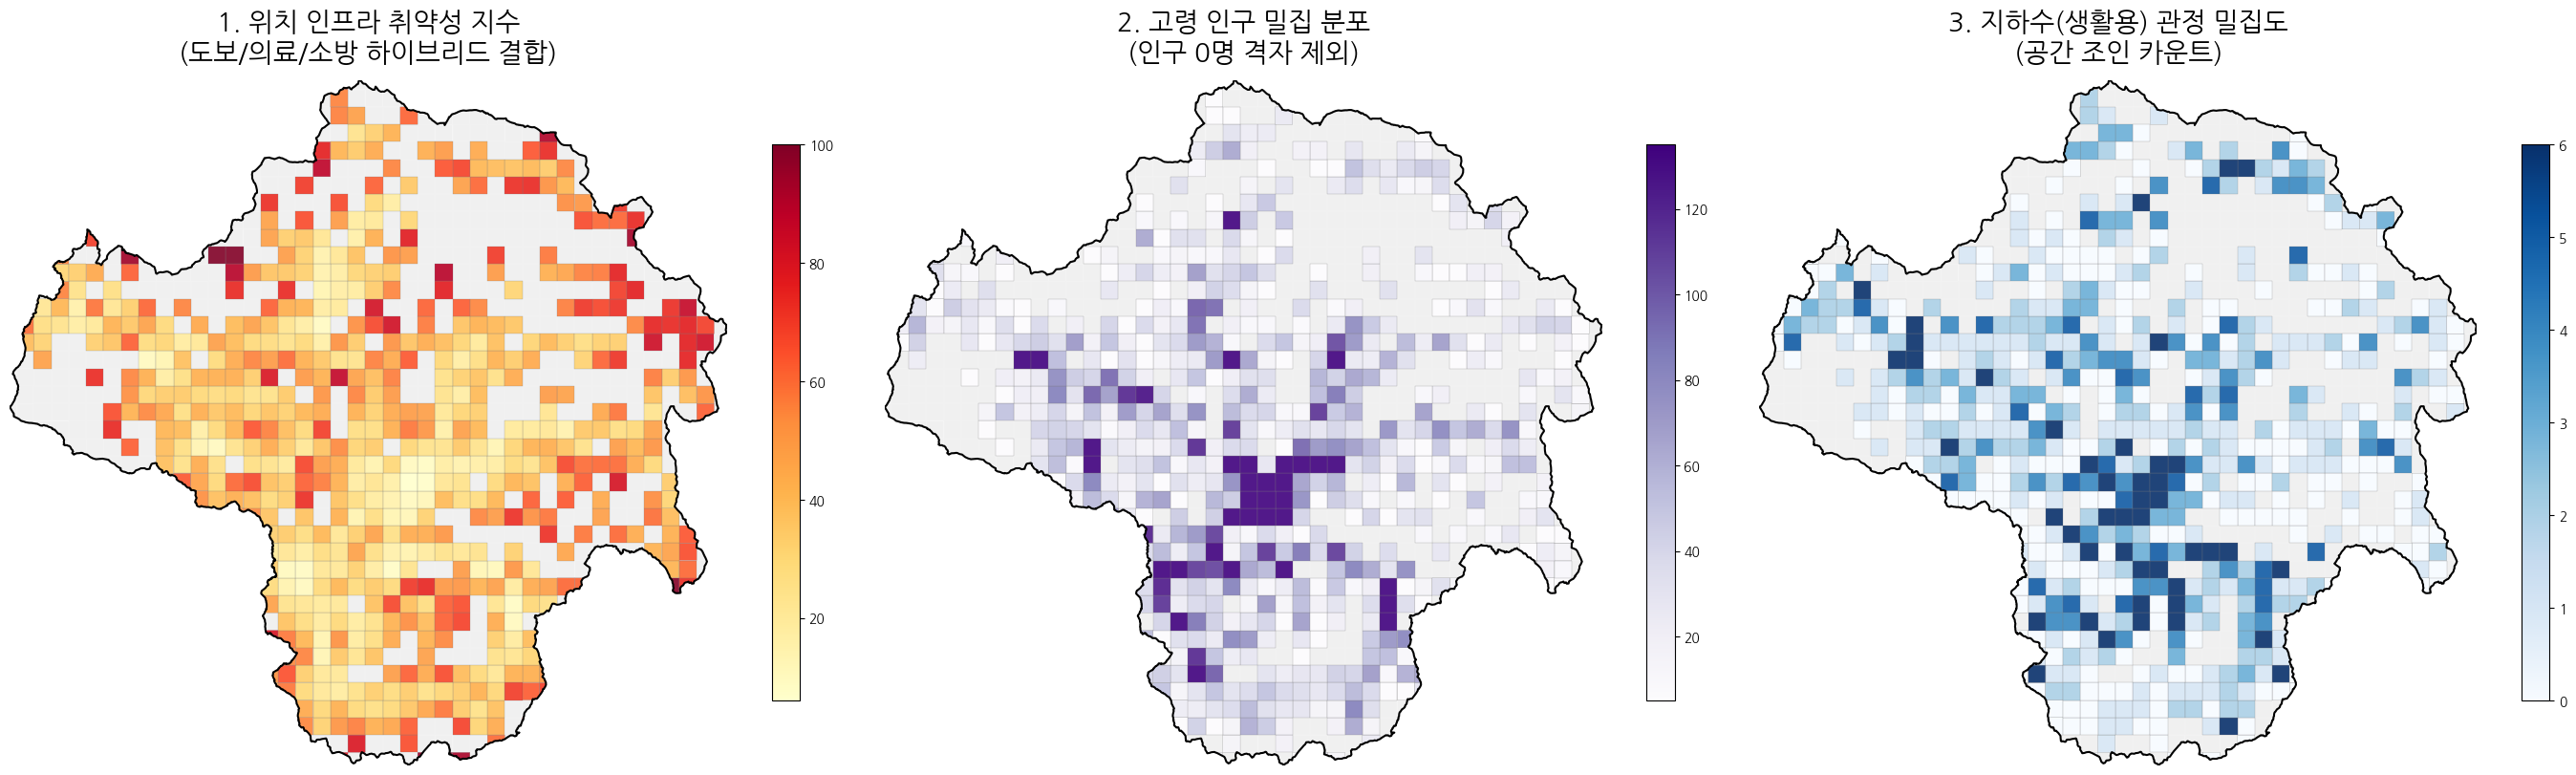

In [7]:
# ==============================================================
# 🎨 [0/4] 한글 폰트 및 라이브러리 설정
# ==============================================================
!apt-get -qq -y install fonts-nanum > /dev/null

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import warnings

warnings.filterwarnings('ignore')

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# ==============================================================
# 🚨 [1/4] 데이터 경로 및 지도 공간 데이터 세팅
# ==============================================================
BASE_DIR = '/content/drive/MyDrive/영천의미학/'

# 파일 경로 (기존 코드 기반)
SHP_PATH = BASE_DIR + '_grid_border_grid_2025_grid_마마_grid_마마/grid_마마_1K.shp'
BORDER_PATH = BASE_DIR + '시군구/bnd_sigungu_37070_2025_2Q.shp'
POP_PATH = BASE_DIR + '2024년_인구_마마_1K_고령전처리.csv'
WATER_PATH = BASE_DIR + '영천시_지하수_생활용_좌표완료.csv'
LOC_PATH = BASE_DIR + 'FINAL_LOCATION_VULNERABILITY_INDEX_HYBRID.csv'

print("🔄 1단계: 영천시 경계 및 격자 도화지를 준비합니다...")

# 영천시 경계 로드 (인코딩 방어 적용)
try: sigungu_map = gpd.read_file(BORDER_PATH, encoding='utf-8')
except: sigungu_map = gpd.read_file(BORDER_PATH, encoding='cp949')
sigungu_map = sigungu_map.to_crs(epsg=5179)
sigungu_map['SIGUNGU_NM'] = sigungu_map['SIGUNGU_NM'].astype(str).str.strip()
yeongcheon_border = sigungu_map[sigungu_map['SIGUNGU_NM'].str.contains('영천', na=False)].copy()

# 격자 로드 및 클리핑
try: grid_map = gpd.read_file(SHP_PATH, encoding='utf-8').set_crs(epsg=5179, allow_override=True)
except: grid_map = gpd.read_file(SHP_PATH, encoding='cp949').set_crs(epsg=5179, allow_override=True)
yeongcheon_grid = gpd.clip(grid_map, yeongcheon_border)
grid_col = yeongcheon_grid.columns[0]
yeongcheon_grid[grid_col] = yeongcheon_grid[grid_col].astype(str).str.strip()

# ==============================================================
# 🧩 [2/4] 3가지 핵심 지표 데이터 로드 및 병합
# ==============================================================
print("🧩 2단계: 3가지 핵심 지표(위치, 고령인구, 지하수)를 결합합니다...")

# 1. 고령인구 병합
df_pop = pd.read_csv(POP_PATH)
pop_grid_col = df_pop.columns[0]
df_pop[pop_grid_col] = df_pop[pop_grid_col].astype(str).str.strip()

# 2. 지하수 공간 병합 (팀장님 기존 로직 적용: sjoin 후 count)
df_water = pd.read_csv(WATER_PATH).dropna(subset=['위도', '경도'])
gdf_water = gpd.GeoDataFrame(df_water, geometry=gpd.points_from_xy(df_water['경도'], df_water['위도']), crs="EPSG:4326").to_crs(epsg=5179)
joined_water = gpd.sjoin(gdf_water, yeongcheon_grid, how='inner', predicate='within')
water_counts = joined_water.groupby(grid_col).size().reset_index(name='water_wells')

# 3. 최종 위치 인프라 병합
df_loc = pd.read_csv(LOC_PATH)
df_loc['grid_id'] = df_loc['grid_id'].astype(str).str.strip()

# 종합 병합 (Left Join)
final_map = yeongcheon_grid.merge(df_loc[['grid_id', 'final_hybrid_score_100']], left_on=grid_col, right_on='grid_id', how='left')
final_map = final_map.merge(df_pop[[pop_grid_col, '고령인구_합계']], left_on=grid_col, right_on=pop_grid_col, how='left')
final_map = final_map.merge(water_counts, on=grid_col, how='left')

# 결측치 0 처리
final_map['고령인구_합계'] = final_map['고령인구_합계'].fillna(0)
final_map['water_wells'] = final_map['water_wells'].fillna(0)

# ==============================================================
# 🗺️ [3/4] 마스터 히트맵 3종 세트 렌더링 (인구 0명 제외 로직 포함)
# ==============================================================
print("🗺️ 3단계: 고령인구 0명 격자를 제외한 마스터 히트맵을 렌더링합니다...")

fig, axes = plt.subplots(1, 3, figsize=(28, 10))
minx, miny, maxx, maxy = yeongcheon_border.total_bounds

# 🌟 인구 0명 마스킹 분리
mask_empty = final_map['고령인구_합계'] <= 0
empty_map = final_map[mask_empty]
valid_map = final_map[~mask_empty]

# Capping (시각화 색상 대비를 위해 상위 % 극단치 제어)
pop_vmax = max(valid_map['고령인구_합계'].quantile(0.95), 10)
water_vmax = max(valid_map['water_wells'].quantile(0.95), 5)

def plot_basemap(ax, title):
    # 경계선 그리기
    yeongcheon_border.boundary.plot(ax=ax, color='black', linewidth=1.5, zorder=3)
    # 인구 0명 격자 회색 처리
    empty_map.plot(ax=ax, color='#f0f0f0', edgecolor='whitesmoke', linewidth=0.3, zorder=1)

    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    ax.set_title(title, fontsize=20, fontweight='bold', pad=15)
    ax.axis('off')

# 🔴 [Map 1] 3대 인프라 융합 '위치 취약성' 히트맵
plot_basemap(axes[0], "1. 위치 인프라 취약성 지수\n(도보/의료/소방 하이브리드 결합)")
valid_map.plot(column='final_hybrid_score_100', ax=axes[0], cmap='YlOrRd',
               legend=True, legend_kwds={'shrink': 0.6}, edgecolor='gray', linewidth=0.2, alpha=0.9, zorder=2)

# 🟣 [Map 2] 고령 인구 밀집도 히트맵
plot_basemap(axes[1], "2. 고령 인구 밀집 분포\n(인구 0명 격자 제외)")
valid_map.plot(column='고령인구_합계', ax=axes[1], cmap='Purples', vmax=pop_vmax,
               legend=True, legend_kwds={'shrink': 0.6}, edgecolor='gray', linewidth=0.2, alpha=0.9, zorder=2)

# 🔵 [Map 3] 지하수 시설 분포도
plot_basemap(axes[2], "3. 지하수(생활용) 관정 밀집도\n(공간 조인 카운트)")
valid_map.plot(column='water_wells', ax=axes[2], cmap='Blues', vmax=water_vmax,
               legend=True, legend_kwds={'shrink': 0.6}, edgecolor='gray', linewidth=0.2, alpha=0.9, zorder=2)

# ==============================================================
# 💾 [4/4] 결과 이미지 저장
# ==============================================================
plt.tight_layout()
heatmap_path = BASE_DIR + 'Yeongcheon_3_Master_Indicators_Heatmaps.png'
plt.savefig(heatmap_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"📁 3종 비교 마스터 히트맵이 성공적으로 저장되었습니다: {heatmap_path}")

plt.show()

🔄 상관관계 분석 및 정규화(Capping + MinMax)를 진행합니다...


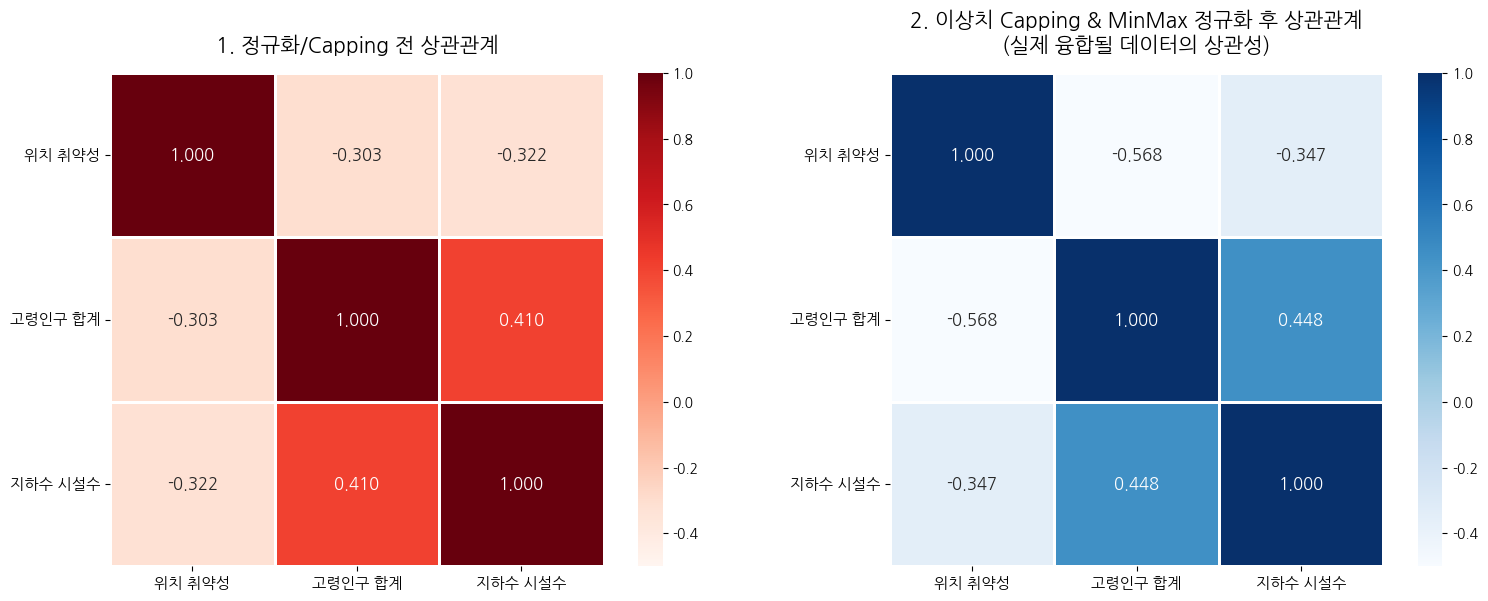

✅ 상관관계 비교 시각화 완료! 데이터가 0~1 사이로 예쁘게 정규화되었습니다.


In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

print("🔄 상관관계 분석 및 정규화(Capping + MinMax)를 진행합니다...")

# ==============================================================
# 1. 분석 대상 컬럼 지정 및 결측치 확인
# ==============================================================
# final_map 데이터프레임이 살아있다고 가정합니다.
# 인구가 0보다 큰 '유효 격자'만 대상으로 상관관계를 분석하는 것이 통계적으로 정확합니다.
valid_df = final_map[final_map['고령인구_합계'] > 0].copy()

cols_raw = ['final_hybrid_score_100', '고령인구_합계', 'water_wells']
cols_names = ['위치 취약성', '고령인구 합계', '지하수 시설수']

# 1-1. 원본 상관계수 계산
corr_raw = valid_df[cols_raw].corr()

# ==============================================================
# 2. 이상치 제어(Capping) 및 정규화(MinMax)
# ==============================================================
# 상위 5% 값으로 극단치를 깎아내어(Capping) 스케일링 시 찌그러짐 방지
cap_pop = valid_df['고령인구_합계'].quantile(0.95)
cap_water = valid_df['water_wells'].quantile(0.95)

valid_df['pop_capped'] = valid_df['고령인구_합계'].clip(upper=cap_pop)
valid_df['water_capped'] = valid_df['water_wells'].clip(upper=cap_water)
valid_df['loc_capped'] = valid_df['final_hybrid_score_100'] # 위치점수는 이미 0~100으로 정규화 및 캡핑된 상태이므로 그대로 사용

cols_capped = ['loc_capped', 'pop_capped', 'water_capped']

# Min-Max 정규화 (0 ~ 1)
scaler = MinMaxScaler()
valid_df[['norm_loc', 'norm_pop', 'norm_water']] = scaler.fit_transform(valid_df[cols_capped])

cols_norm = ['norm_loc', 'norm_pop', 'norm_water']

# 2-1. 정규화(캡핑 반영) 후 상관계수 계산
corr_norm = valid_df[cols_norm].corr()

# ==============================================================
# 3. 상관관계 시각화 (비교)
# ==============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# [왼쪽] 원본 데이터 상관관계
sns.heatmap(corr_raw, annot=True, fmt=".3f", cmap='Reds', vmin=-0.5, vmax=1,
            linewidths=1, square=True, annot_kws={"size": 12, "weight": "bold"}, ax=axes[0])
axes[0].set_title("1. 정규화/Capping 전 상관관계", fontsize=15, fontweight='bold', pad=15)
axes[0].set_xticklabels(cols_names, fontsize=11)
axes[0].set_yticklabels(cols_names, fontsize=11, rotation=0)

# [오른쪽] 정규화(Capping 포함) 후 상관관계
sns.heatmap(corr_norm, annot=True, fmt=".3f", cmap='Blues', vmin=-0.5, vmax=1,
            linewidths=1, square=True, annot_kws={"size": 12, "weight": "bold"}, ax=axes[1])
axes[1].set_title("2. 이상치 Capping & MinMax 정규화 후 상관관계\n(실제 융합될 데이터의 상관성)", fontsize=15, fontweight='bold', pad=15)
axes[1].set_xticklabels(cols_names, fontsize=11)
axes[1].set_yticklabels(cols_names, fontsize=11, rotation=0)

plt.tight_layout()
corr_plot_path = BASE_DIR + 'Master_Indicators_Correlation.png'
plt.savefig(corr_plot_path, dpi=300, bbox_inches='tight')
plt.show()

# 최종 분석에 쓰일 데이터프레임 업데이트 준비 완료
print("✅ 상관관계 비교 시각화 완료! 데이터가 0~1 사이로 예쁘게 정규화되었습니다.")

In [9]:
import numpy as np
import pandas as pd

print("🧠 [1/2] 순수 엔트로피(Entropy) 기반 가중치 산출 알고리즘 실행...")

# 1. 앞서 정규화된 3가지 지표 추출
cols_norm = ['norm_loc', 'norm_pop', 'norm_water']
X = valid_df[cols_norm].copy()

# [안전장치] 정규화 값 중 0이 있으면 로그(log) 계산 시 에러가 나므로 극소값을 더해줌
epsilon = 1e-8
X_safe = X + epsilon

# 2. 지표별 비율(P) 계산
P = X_safe / X_safe.sum(axis=0)

# 3. 엔트로피(E) 및 정보 유용성(d) 계산
n = len(valid_df)
k = 1.0 / np.log(n)
E = -k * (P * np.log(P)).sum(axis=0)
d = 1.0 - E

# 4. 최종 엔트로피 가중치(W) 도출
W_entropy = d / d.sum()

print("\n========================================")
print("⚖️ [순수 엔트로피 가중치 산출 결과]")
print(f"▶ 1. 위치 취약성 : {W_entropy['norm_loc'] * 100:.2f} %")
print(f"▶ 2. 고령 인구수 : {W_entropy['norm_pop'] * 100:.2f} %")
print(f"▶ 3. 지하수 시설 : {W_entropy['norm_water'] * 100:.2f} %")
print("========================================\n")

# 5. 엔트로피 단일 기준 취약도 점수 계산 (100점 만점)
valid_df['score_entropy_only'] = (
    (valid_df['norm_loc'] * W_entropy['norm_loc']) +
    (valid_df['norm_pop'] * W_entropy['norm_pop']) +
    (valid_df['norm_water'] * W_entropy['norm_water'])
) * 100

print("✅ 순수 엔트로피 점수(score_entropy_only) 계산이 완료되었습니다.")

🧠 [1/2] 순수 엔트로피(Entropy) 기반 가중치 산출 알고리즘 실행...

⚖️ [순수 엔트로피 가중치 산출 결과]
▶ 1. 위치 취약성 : 11.44 %
▶ 2. 고령 인구수 : 36.64 %
▶ 3. 지하수 시설 : 51.92 %

✅ 순수 엔트로피 점수(score_entropy_only) 계산이 완료되었습니다.


In [10]:
print("🎯 [2/2] 하이브리드(Entropy + AHP) 기반 최종 가중치 융합 알고리즘 실행...")

# ==============================================================
# ⭐⭐⭐ [AHP 정책 가중치 설정] 팀장님, 여기서 비율을 자유롭게 수정하세요! ⭐⭐⭐
# 순서: [위치 인프라, 고령 인구, 지하수 시설]
# 주의: 세 숫자의 합이 반드시 1.0 (100%)이 되도록 맞춰주세요.
# ==============================================================
AHP_RATIO = np.array([0.40, 0.40, 0.20])
# ==============================================================

# 1. 이전 코드에서 구한 엔트로피 가중치 배열화
W_ent_arr = np.array([W_entropy['norm_loc'], W_entropy['norm_pop'], W_entropy['norm_water']])

# 2. 🌟 승산 정규화 (Multiplicative Normalization) 결합
W_hybrid_raw = W_ent_arr * AHP_RATIO
W_hybrid = W_hybrid_raw / W_hybrid_raw.sum()

hybrid_weights = {
    'norm_loc': W_hybrid[0],
    'norm_pop': W_hybrid[1],
    'norm_water': W_hybrid[2]
}

print("\n========================================")
print("🏆 [최종 하이브리드 가중치 융합 결과]")
print(f"▶ 위치 인프라 : Entropy({W_ent_arr[0]*100:.1f}%) x AHP({AHP_RATIO[0]*100:.1f}%) ➡️ [최종 {hybrid_weights['norm_loc'] * 100:.2f} %]")
print(f"▶ 고령 인구수 : Entropy({W_ent_arr[1]*100:.1f}%) x AHP({AHP_RATIO[1]*100:.1f}%) ➡️ [최종 {hybrid_weights['norm_pop'] * 100:.2f} %]")
print(f"▶ 지하수 시설 : Entropy({W_ent_arr[2]*100:.1f}%) x AHP({AHP_RATIO[2]*100:.1f}%) ➡️ [최종 {hybrid_weights['norm_water'] * 100:.2f} %]")
print("========================================\n")

# 3. 하이브리드 최종 종합 점수 계산 (100점 만점)
valid_df['score_hybrid_final'] = (
    (valid_df['norm_loc'] * hybrid_weights['norm_loc']) +
    (valid_df['norm_pop'] * hybrid_weights['norm_pop']) +
    (valid_df['norm_water'] * hybrid_weights['norm_water'])
) * 100

# 4. 결과 비교 출력 (엔트로피 vs 하이브리드 상위 10개 격자)
print("🔍 [결과 비교] 하이브리드 점수 기준 영천시 상위 위험 격자 Top 10:")
display(valid_df[['grid_id', 'score_entropy_only', 'score_hybrid_final']].sort_values(by='score_hybrid_final', ascending=False).head(10).round(2))

🎯 [2/2] 하이브리드(Entropy + AHP) 기반 최종 가중치 융합 알고리즘 실행...

🏆 [최종 하이브리드 가중치 융합 결과]
▶ 위치 인프라 : Entropy(11.4%) x AHP(40.0%) ➡️ [최종 15.45 %]
▶ 고령 인구수 : Entropy(36.6%) x AHP(40.0%) ➡️ [최종 49.48 %]
▶ 지하수 시설 : Entropy(51.9%) x AHP(20.0%) ➡️ [최종 35.06 %]

🔍 [결과 비교] 하이브리드 점수 기준 영천시 상위 위험 격자 Top 10:


,grid_id,score_entropy_only,score_hybrid_final
242,마마2874,91.12,88.01
233,마마2672,90.75,87.50
214,마마3071,90.72,87.47
248,마마2976,89.89,86.34
246,마마2975,89.65,86.02
237,마마2774,89.57,85.91
524,마마1683,89.47,85.78
243,마마2974,89.47,85.78
619,마마3077,89.04,85.19
244,마마3075,89.03,85.19


🏆 대망의 최종 마스터 취약지수 분석 및 시각화를 시작합니다...

✅ 최종 마스터 데이터가 저장되었습니다: /content/drive/MyDrive/영천의미학/Yeongcheon_Master_Vulnerability_Final.csv

🚨 [영천시 찐 사각지대 Top 10 심층 분석 리포트] 🚨
🥇 [Rank 1] 격자: 마마2874 (최종 점수: 88.0점)
   📍 핵심 취약 원인: 고령인구 밀집 (점수 기여도 56.2%)
   📊 실제 데이터: 고령인구 347명 | 지하수 6개 | 위치인프라 27.1점
   ⚖️ 지표별 기여도: 인구(56.2%) / 지하수(39.8%) / 위치(3.9%)
------------------------------------------------------------
🥇 [Rank 2] 격자: 마마2672 (최종 점수: 87.5점)
   📍 핵심 취약 원인: 고령인구 밀집 (점수 기여도 56.6%)
   📊 실제 데이터: 고령인구 487명 | 지하수 7개 | 위치인프라 24.0점
   ⚖️ 지표별 기여도: 인구(56.6%) / 지하수(40.1%) / 위치(3.4%)
------------------------------------------------------------
🥇 [Rank 3] 격자: 마마3071 (최종 점수: 87.5점)
   📍 핵심 취약 원인: 고령인구 밀집 (점수 기여도 56.6%)
   📊 실제 데이터: 고령인구 186명 | 지하수 6개 | 위치인프라 23.8점
   ⚖️ 지표별 기여도: 인구(56.6%) / 지하수(40.1%) / 위치(3.3%)
------------------------------------------------------------
🥇 [Rank 4] 격자: 마마2976 (최종 점수: 86.3점)
   📍 핵심 취약 원인: 고령인구 밀집 (점수 기여도 57.3%)
   📊 실제 데이터: 고령인구 1354명 | 지하수 10개 | 위치인프라 16.9점
   ⚖️ 지표별 기여도: 인구

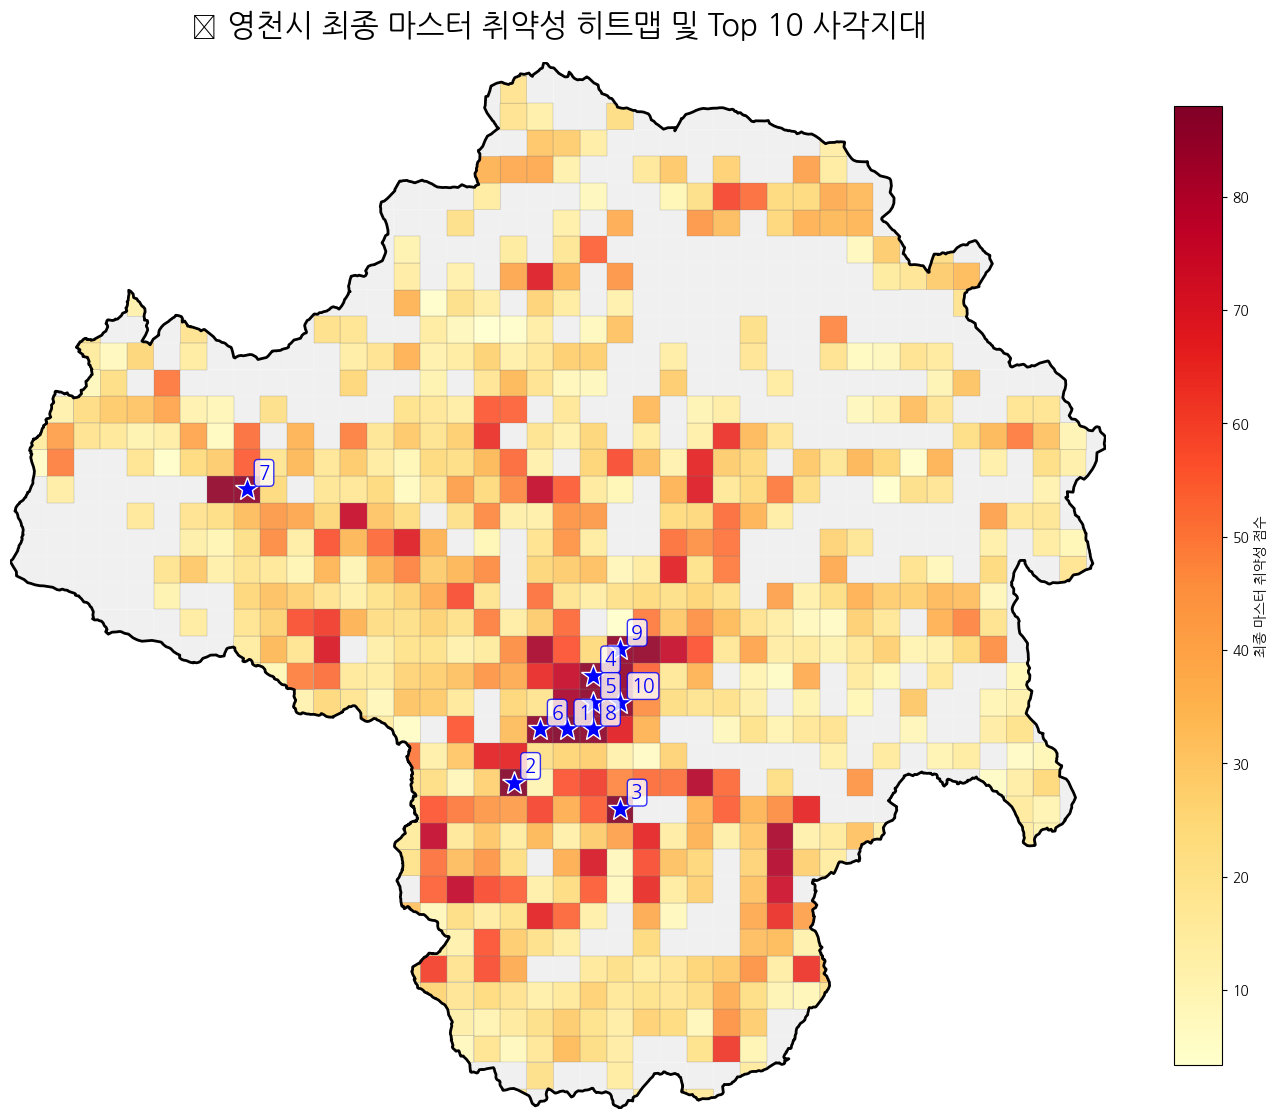

In [11]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

print("🏆 대망의 최종 마스터 취약지수 분석 및 시각화를 시작합니다...\n")

# ==============================================================
# 💾 [1/3] 최종 데이터 정리 및 CSV 저장
# ==============================================================
# 최종 저장할 핵심 컬럼만 추리기
save_cols = [
    'grid_id', '고령인구_합계', 'water_wells', 'final_hybrid_score_100',
    'norm_loc', 'norm_pop', 'norm_water', 'score_hybrid_final', 'geometry'
]

# 컬럼명 직관적으로 변경 (옵션)
final_export = valid_df[save_cols].rename(columns={
    'final_hybrid_score_100': '위치인프라_점수',
    'water_wells': '지하수_시설수',
    'score_hybrid_final': '최종_종합_취약점수'
})

# CSV 및 GeoJSON 저장
export_path_csv = BASE_DIR + 'Yeongcheon_Master_Vulnerability_Final.csv'
final_export.drop(columns='geometry').to_csv(export_path_csv, index=False, encoding='utf-8-sig')
print(f"✅ 최종 마스터 데이터가 저장되었습니다: {export_path_csv}")

# ==============================================================
# 🔍 [2/3] 영천시 최악의 찐 사각지대 Top 10 원인 분석 리포트
# ==============================================================
top10_df = final_export.sort_values(by='최종_종합_취약점수', ascending=False).head(10)

print("\n🚨 [영천시 찐 사각지대 Top 10 심층 분석 리포트] 🚨")
print("=" * 60)

for rank, (idx, row) in enumerate(top10_df.iterrows(), start=1):
    grid = row['grid_id']
    total_score = row['최종_종합_취약점수']

    # 각 지표가 최종 점수에 기여한 '비중(%)' 계산
    # (각 정규화 점수 * 하이브리드 가중치) / 전체 점수
    contrib_loc = (row['norm_loc'] * hybrid_weights['norm_loc'] * 100) / total_score * 100
    contrib_pop = (row['norm_pop'] * hybrid_weights['norm_pop'] * 100) / total_score * 100
    contrib_water = (row['norm_water'] * hybrid_weights['norm_water'] * 100) / total_score * 100

    # 가장 기여도가 높은 1순위 치명적 원인 찾기
    causes = {'위치/인프라': contrib_loc, '고령인구 밀집': contrib_pop, '지하수 의존/고갈': contrib_water}
    main_cause = max(causes, key=causes.get)

    print(f"🥇 [Rank {rank}] 격자: {grid} (최종 점수: {total_score:.1f}점)")
    print(f"   📍 핵심 취약 원인: {main_cause} (점수 기여도 {causes[main_cause]:.1f}%)")
    print(f"   📊 실제 데이터: 고령인구 {row['고령인구_합계']:.0f}명 | 지하수 {row['지하수_시설수']:.0f}개 | 위치인프라 {row['위치인프라_점수']:.1f}점")
    print(f"   ⚖️ 지표별 기여도: 인구({contrib_pop:.1f}%) / 지하수({contrib_water:.1f}%) / 위치({contrib_loc:.1f}%)")
    print("-" * 60)

# ==============================================================
# 🗺️ [3/3] 최종 마스터 취약성 히트맵 + Top 10 핀 시각화
# ==============================================================
fig, ax = plt.subplots(figsize=(14, 14))
minx, miny, maxx, maxy = yeongcheon_border.total_bounds

# 1. 배경 및 경계선
yeongcheon_border.boundary.plot(ax=ax, color='black', linewidth=2, zorder=3)
empty_map.plot(ax=ax, color='#f0f0f0', edgecolor='whitesmoke', linewidth=0.3, zorder=1) # 인구 0명 회색

# 2. 종합 취약지수 히트맵 렌더링 (진한 빨간색일수록 위험)
valid_df.plot(column='score_hybrid_final', ax=ax, cmap='YlOrRd',
              legend=True, legend_kwds={'shrink': 0.7, 'label': '최종 마스터 취약성 점수'},
              edgecolor='gray', linewidth=0.2, alpha=0.9, zorder=2)

# 3. Top 10 격자에 마커(별) 찍고 등수 달기
for rank, (idx, row) in enumerate(top10_df.iterrows(), start=1):
    centroid = row['geometry'].centroid

    # 별 마커
    ax.plot(centroid.x, centroid.y, marker='*', color='blue', markersize=18, markeredgecolor='white', markeredgewidth=1, zorder=4)

    # 등수 텍스트 (마커 약간 우측 상단에 배치)
    ax.annotate(f"{rank}", xy=(centroid.x, centroid.y), xytext=(8, 8), textcoords="offset points",
                fontsize=14, fontweight='bold', color='blue', zorder=5,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="blue", lw=1, alpha=0.8))

# 디자인 마무리
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_title("🚨 영천시 최종 마스터 취약성 히트맵 및 Top 10 사각지대", fontsize=22, fontweight='bold', pad=20)
ax.axis('off')

# 파일 저장 및 출력
final_map_path = BASE_DIR + 'Yeongcheon_Master_Top10_Map.png'
plt.tight_layout()
plt.savefig(final_map_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"📁 Top 10 마스터 히트맵이 저장되었습니다: {final_map_path}")

plt.show()

In [12]:
import numpy as np
import pandas as pd

print("🛡️ [코드 1] A방식(도심지 컷오프) + C방식(가중치 조절) 모델 실행...")

# ==============================================================
# 🌟 [C방식 적용] 지하수 가중치 대폭 축소 (AHP 비율 조절)
# 순서: [위치 인프라, 고령 인구, 지하수 시설]
# ==============================================================
AHP_RATIO_AC = np.array([0.50, 0.40, 0.10])  # 위치 50%, 인구 40%, 지하수 10%
# ==============================================================

# 1. 하이브리드 가중치 재계산 (승산 정규화)
W_ent_arr = np.array([W_entropy['norm_loc'], W_entropy['norm_pop'], W_entropy['norm_water']])
W_hybrid_raw_ac = W_ent_arr * AHP_RATIO_AC
W_hybrid_ac = W_hybrid_raw_ac / W_hybrid_raw_ac.sum()

weights_ac = {'loc': W_hybrid_ac[0], 'pop': W_hybrid_ac[1], 'water': W_hybrid_ac[2]}

print(f"⚖️ [조정된 가중치] 위치: {weights_ac['loc']*100:.1f}% | 인구: {weights_ac['pop']*100:.1f}% | 지하수: {weights_ac['water']*100:.1f}%")

# 2. 덧셈(Additive) 기반 점수 산출
valid_df['score_method_A'] = (
    (valid_df['norm_loc'] * weights_ac['loc']) +
    (valid_df['norm_pop'] * weights_ac['pop']) +
    (valid_df['norm_water'] * weights_ac['water'])
) * 100

# ==============================================================
# 🌟 [A방식 적용] 인프라 양호 구역(도심지) Cut-off 필터링
# ==============================================================
# 위치 취약성(norm_loc)이 하위 30%인 곳(인프라가 가장 좋은 30%)을 탈락시킴
cut_off_threshold = valid_df['norm_loc'].quantile(0.30)
filtered_df_A = valid_df[valid_df['norm_loc'] >= cut_off_threshold].copy()

print(f"\n✂️ [Cut-off 적용] 인프라 양호 도심지 {len(valid_df) - len(filtered_df_A)}개 격자 심사 제외 완료!")

# 3. Top 10 결과 출력
top10_A = filtered_df_A.sort_values(by='score_method_A', ascending=False).head(10)

print("\n🚨 [결과 A] 도심지 컷오프 모델 기준 Top 10 찐 사각지대 🚨")
display(top10_A[['grid_id', '고령인구_합계', 'water_wells', 'score_method_A', 'norm_loc']].round(2))

🛡️ [코드 1] A방식(도심지 컷오프) + C방식(가중치 조절) 모델 실행...
⚖️ [조정된 가중치] 위치: 22.4% | 인구: 57.3% | 지하수: 20.3%

✂️ [Cut-off 적용] 인프라 양호 도심지 191개 격자 심사 제외 완료!

🚨 [결과 A] 도심지 컷오프 모델 기준 Top 10 찐 사각지대 🚨


,grid_id,고령인구_합계,water_wells,score_method_A,norm_loc
459,마마2082,95.0,7.0,68.95,0.40
208,마마2771,234.0,1.0,67.03,0.28
820,마마3384,108.0,4.0,64.90,0.27
186,마마2969,72.0,11.0,64.52,0.66
196,마마3170,57.0,9.0,59.66,0.73
234,마마2573,75.0,9.0,59.39,0.37
30,마마2273,124.0,0.0,58.88,0.29
823,마마3485,80.0,5.0,58.64,0.39
660,마마2578,120.0,0.0,58.03,0.33
191,마마3168,70.0,6.0,56.76,0.35


In [13]:
print("✖️ [코드 2] B방식(곱셈 융합) + C방식(가중치 조절) 모델 실행...")

# ==============================================================
# 🌟 [C방식 적용] 지하수 가중치 대폭 축소 (AHP 비율 조절)
# ==============================================================
AHP_RATIO_BC = np.array([0.50, 0.40, 0.10])  # 위치 50%, 인구 40%, 지하수 10%
# ==============================================================

# 1. 하이브리드 가중치 재계산 (코드 1과 동일한 가중치 사용)
W_hybrid_raw_bc = W_ent_arr * AHP_RATIO_BC
W_hybrid_bc = W_hybrid_raw_bc / W_hybrid_raw_bc.sum()
weights_bc = {'loc': W_hybrid_bc[0], 'pop': W_hybrid_bc[1], 'water': W_hybrid_bc[2]}

# ==============================================================
# 🌟 [B방식 적용] 곱셈(Multiplicative) 기반 점수 산출
# ==============================================================
# 데이터에 0이 있으면 곱셈 시 전체가 0이 되므로, 극소값(0.01)을 더해줌
loc_safe = valid_df['norm_loc'] + 0.01
pop_safe = valid_df['norm_pop'] + 0.01
water_safe = valid_df['norm_water'] + 0.01

# 가중 기하 평균 공식: 각 지표의 점수를 '가중치만큼 제곱'하여 모두 곱함
valid_df['score_method_B'] = (
    (loc_safe ** weights_bc['loc']) * (pop_safe ** weights_bc['pop']) * (water_safe ** weights_bc['water'])
)

# 보기 좋게 0~100 스케일로 단순 변환 (최대값 기준 상대 평가)
valid_df['score_method_B_100'] = (valid_df['score_method_B'] / valid_df['score_method_B'].max()) * 100

# 2. Top 10 결과 출력
top10_B = valid_df.sort_values(by='score_method_B_100', ascending=False).head(10)

print("\n🚨 [결과 B] 곱셈 융합(기하평균) 모델 기준 Top 10 찐 사각지대 🚨")
display(top10_B[['grid_id', '고령인구_합계', 'water_wells', 'score_method_B_100', 'norm_loc']].round(2))

✖️ [코드 2] B방식(곱셈 융합) + C방식(가중치 조절) 모델 실행...

🚨 [결과 B] 곱셈 융합(기하평균) 모델 기준 Top 10 찐 사각지대 🚨


,grid_id,고령인구_합계,water_wells,score_method_B_100,norm_loc
242,마마2874,347.0,6.0,100.00,0.22
233,마마2672,487.0,7.0,96.66,0.19
214,마마3071,186.0,6.0,96.43,0.19
15,마마2468,135.0,4.0,92.95,0.23
459,마마2082,95.0,7.0,92.06,0.40
697,마마2783,135.0,4.0,89.82,0.20
629,마마2777,138.0,5.0,89.66,0.16
247,마마2876,217.0,4.0,88.16,0.18
265,마마3670,223.0,5.0,87.61,0.14
248,마마2976,1354.0,10.0,87.06,0.12


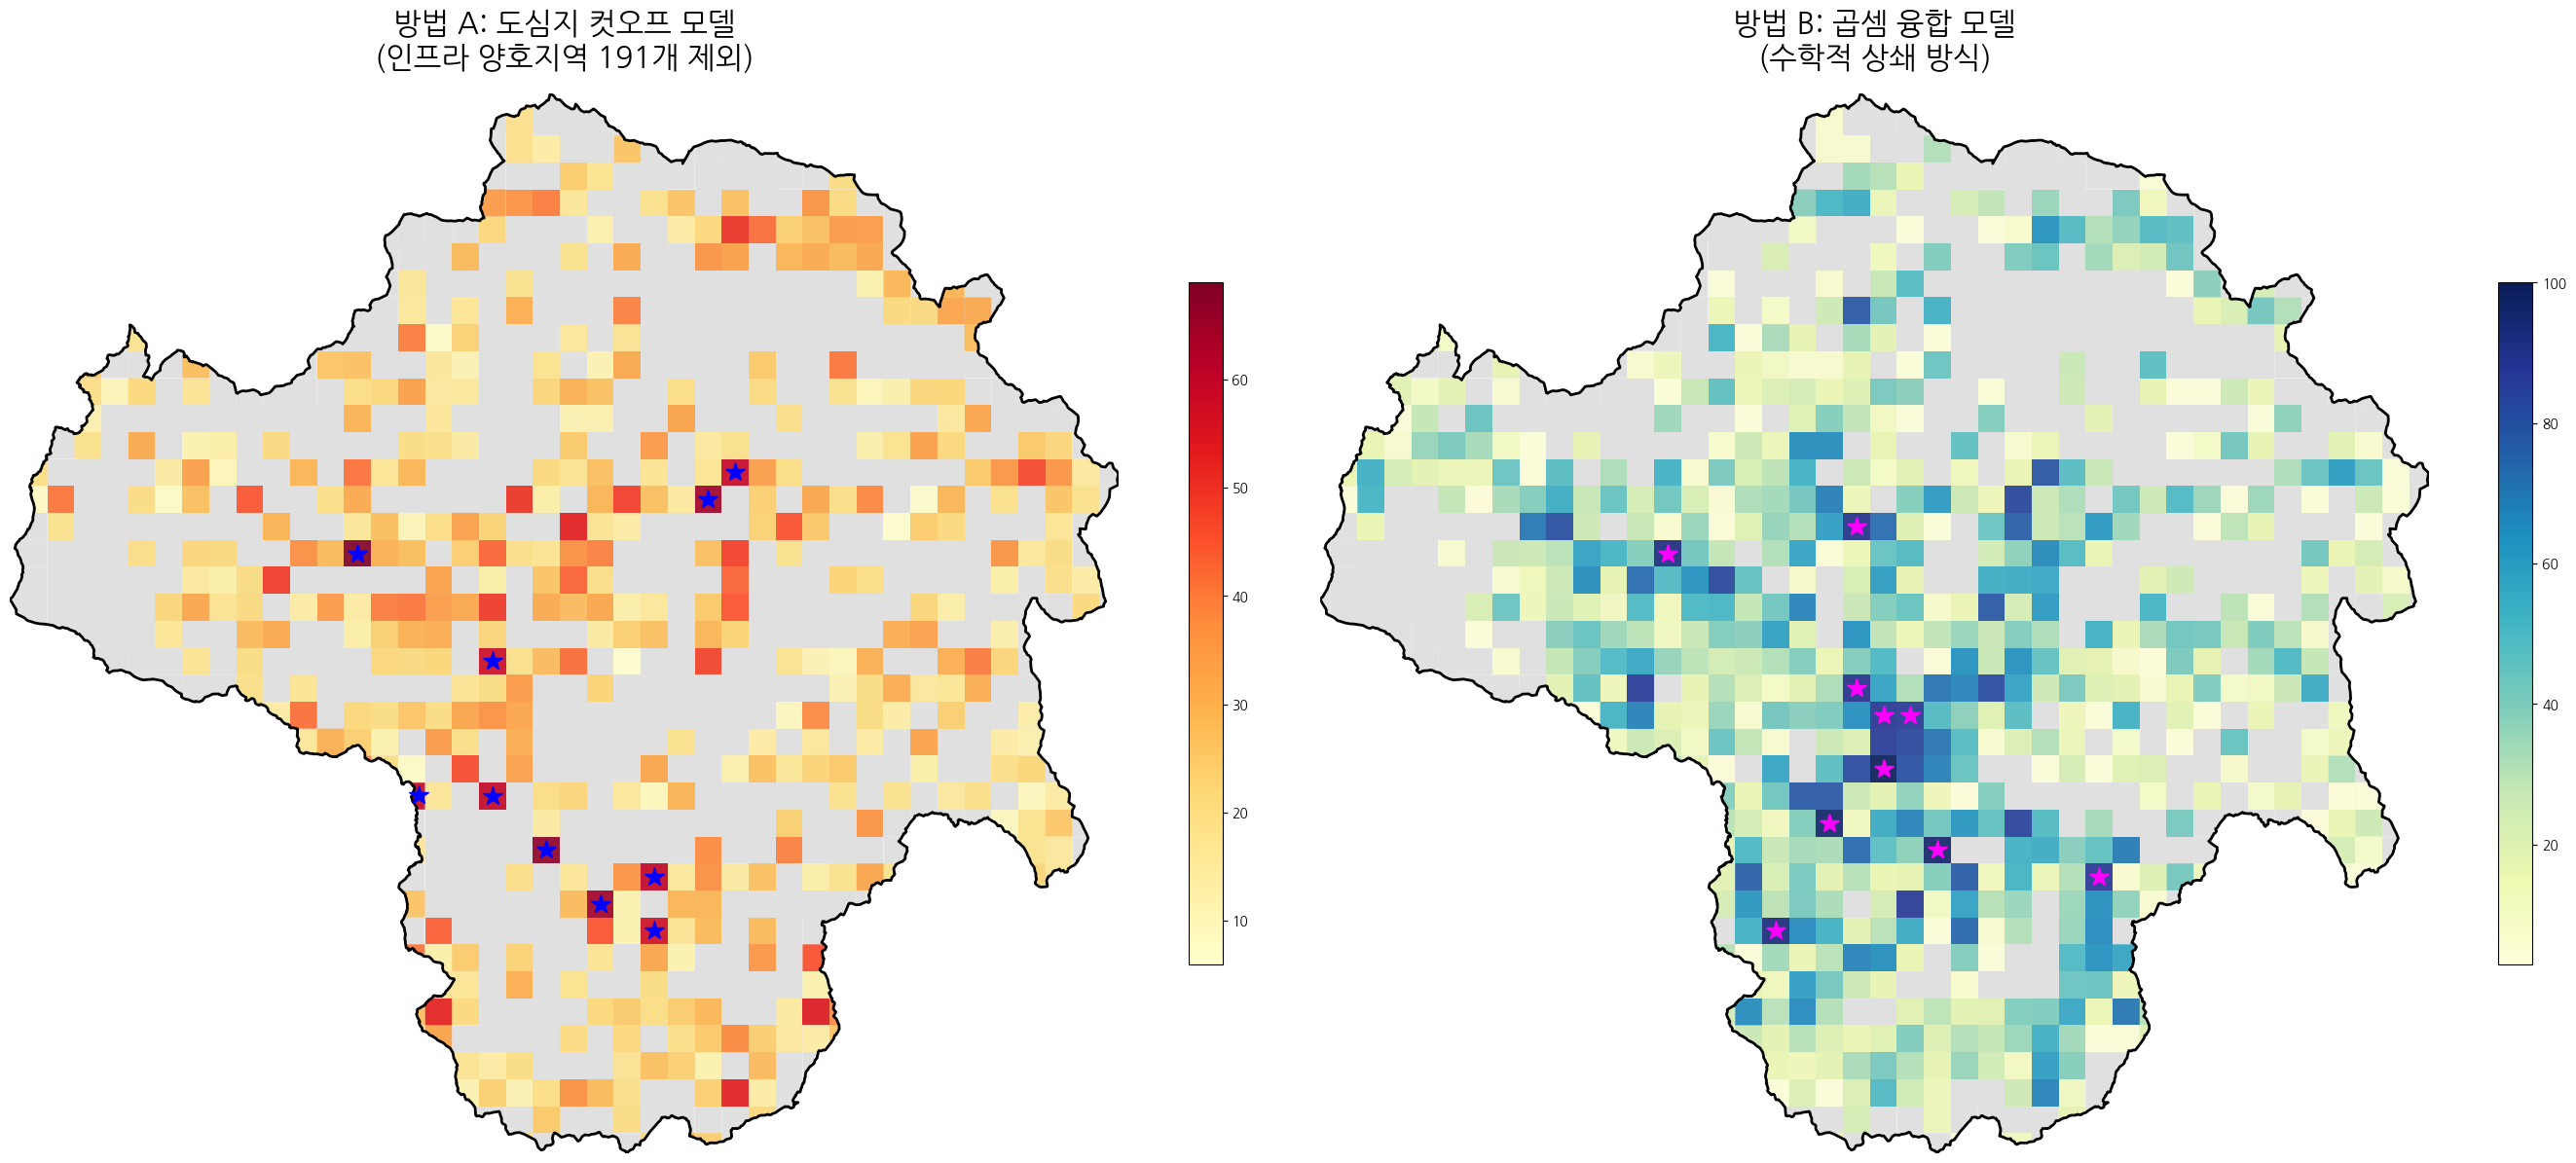

📁 비교 지도가 저장되었습니다: /content/drive/MyDrive/영천의미학/Method_A_vs_B_Comparison.png


In [14]:
import matplotlib.pyplot as plt

# ==============================================================
# 🎨 시각화 세팅: 모델 A와 모델 B 나란히 비교
# ==============================================================
fig, axes = plt.subplots(1, 2, figsize=(28, 12))
minx, miny, maxx, maxy = yeongcheon_border.total_bounds

# --- [공통 함수] 지도 배경 및 도심지 회색 처리 ---
def plot_base(ax, title, target_df):
    yeongcheon_border.boundary.plot(ax=ax, color='black', linewidth=2, zorder=3)
    # 인구 0명 + 분석 제외(NaN) 구역은 연한 회색 처리
    final_map.plot(ax=ax, color='#e0e0e0', edgecolor='none', zorder=1)
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    ax.set_title(title, fontsize=22, fontweight='bold', pad=20)
    ax.axis('off')

# 🔴 [왼쪽] 모델 A 시각화 (컷오프 적용)
plot_base(axes[0], "방법 A: 도심지 컷오프 모델\n(인프라 양호지역 191개 제외)", filtered_df_A)
filtered_df_A.plot(column='score_method_A', ax=axes[0], cmap='YlOrRd',
                  legend=True, legend_kwds={'shrink': 0.6}, alpha=0.9, zorder=2)

# Top 10 별 표시 (모델 A)
for idx, row in top10_A.iterrows():
    centroid = row['geometry'].centroid
    axes[0].plot(centroid.x, centroid.y, marker='*', color='blue', markersize=15, zorder=4)

# 🔵 [오른쪽] 모델 B 시각화 (곱셈 융합)
plot_base(axes[1], "방법 B: 곱셈 융합 모델\n(수학적 상쇄 방식)", valid_df)
valid_df.plot(column='score_method_B_100', ax=axes[1], cmap='YlGnBu',
             legend=True, legend_kwds={'shrink': 0.6}, alpha=0.9, zorder=2)

# Top 10 별 표시 (모델 B)
for idx, row in top10_B.iterrows():
    centroid = row['geometry'].centroid
    axes[1].plot(centroid.x, centroid.y, marker='*', color='magenta', markersize=15, zorder=4)

plt.tight_layout()
comparison_path = BASE_DIR + 'Method_A_vs_B_Comparison.png'
plt.savefig(comparison_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"📁 비교 지도가 저장되었습니다: {comparison_path}")

🎨 지도를 꽉 채우면서 논리를 지키는 [Safe Zone 레이어 분리 시각화]를 시작합니다...
📁 꽉 찬 최종 마스터 히트맵이 저장되었습니다: /content/drive/MyDrive/영천의미학/Yeongcheon_Final_Master_Map_Filled.png


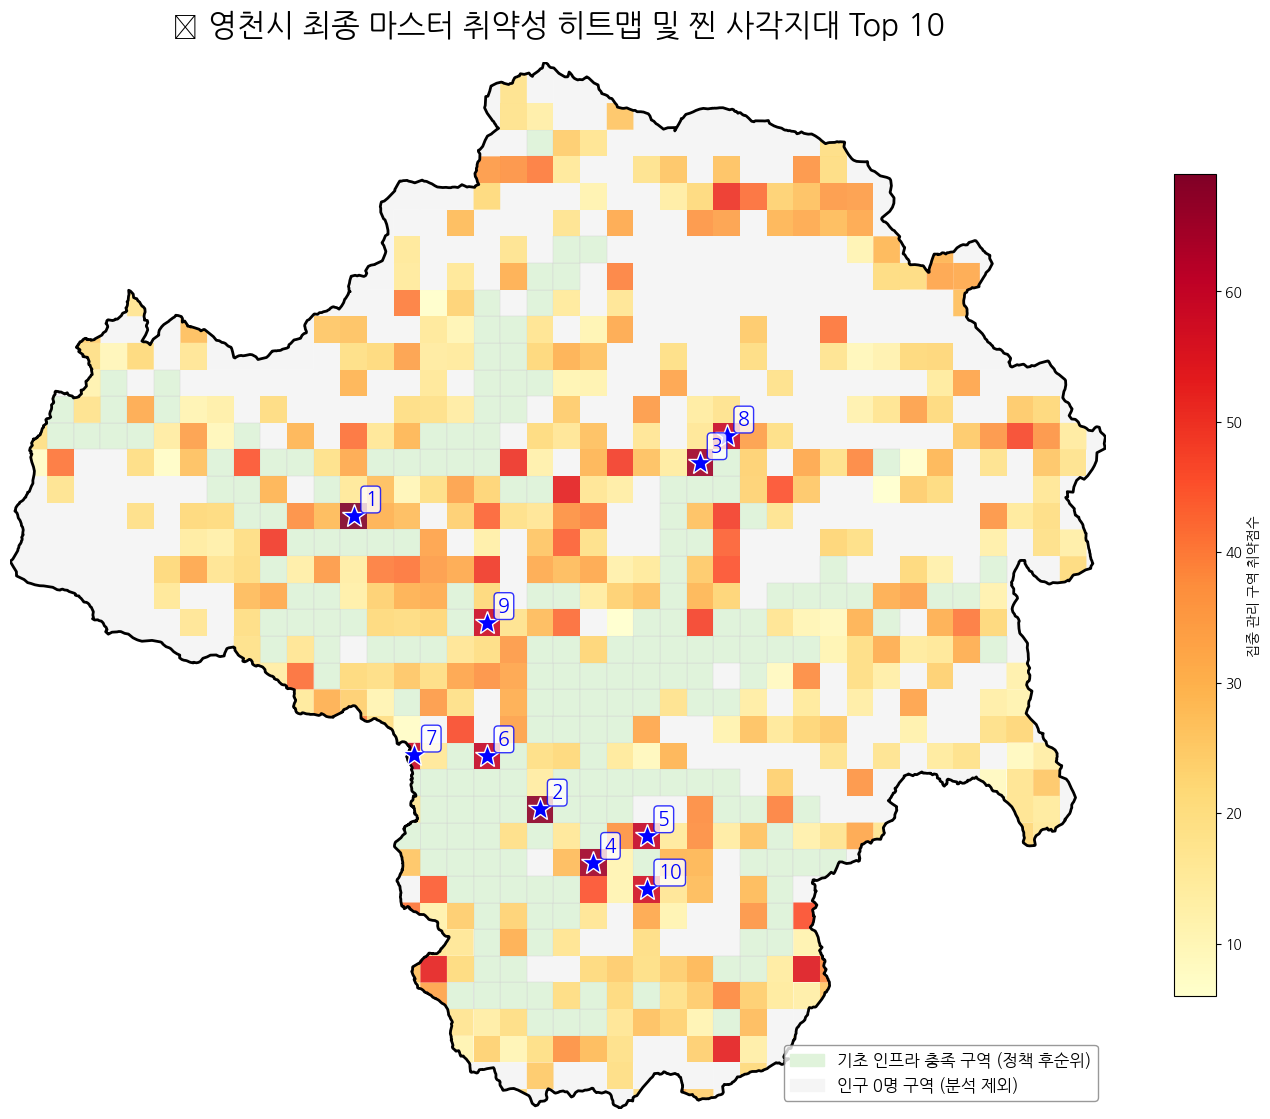

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print("🎨 지도를 꽉 채우면서 논리를 지키는 [Safe Zone 레이어 분리 시각화]를 시작합니다...")

fig, ax = plt.subplots(figsize=(14, 14))
minx, miny, maxx, maxy = yeongcheon_border.total_bounds

# ==============================================================
# 1. 배경 및 경계선 렌더링
# ==============================================================
yeongcheon_border.boundary.plot(ax=ax, color='black', linewidth=2, zorder=4)

# 아예 인구가 0명인 유령 격자 (연한 회색)
empty_map.plot(ax=ax, color='#f5f5f5', edgecolor='whitesmoke', linewidth=0.3, zorder=1)

# ==============================================================
# 2. [핵심] 도심지(인프라 상위 30%) 격자를 초록색(Safe Zone)으로 칠하기
# ==============================================================
# A방식에서 필터링되었던 191개 격자 추출
cut_off_threshold = valid_df['norm_loc'].quantile(0.30)
safe_zone_df = valid_df[valid_df['norm_loc'] < cut_off_threshold]

# 삭제하지 않고 연한 초록색/민트색으로 렌더링하여 지도 채우기
safe_zone_df.plot(ax=ax, color='#e0f3db', edgecolor='lightgray', linewidth=0.3, zorder=2)

# ==============================================================
# 3. 집중 관리 타겟 구역 (붉은색 히트맵) 렌더링
# ==============================================================
# A방식에서 살아남은 격자들만 히트맵으로 칠하기
filtered_df_A.plot(column='score_method_A', ax=ax, cmap='YlOrRd',
                   legend=True, legend_kwds={'shrink': 0.6, 'label': '집중 관리 구역 취약점수'},
                   alpha=0.9, zorder=3)

# ==============================================================
# 4. Top 10 별 마커 찍기
# ==============================================================
for rank, (idx, row) in enumerate(top10_A.iterrows(), start=1):
    centroid = row['geometry'].centroid
    ax.plot(centroid.x, centroid.y, marker='*', color='blue', markersize=18, markeredgecolor='white', markeredgewidth=1, zorder=5)
    ax.annotate(f"{rank}", xy=(centroid.x, centroid.y), xytext=(8, 8), textcoords="offset points",
                fontsize=14, fontweight='bold', color='blue', zorder=6,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="blue", lw=1, alpha=0.8))

# ==============================================================
# 5. 디자인 마무리 및 커스텀 범례(Legend) 추가
# ==============================================================
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)
ax.set_title("🚨 영천시 최종 마스터 취약성 히트맵 및 찐 사각지대 Top 10", fontsize=22, fontweight='bold', pad=20)
ax.axis('off')

# 시각적 설명을 위한 커스텀 범례
safe_patch = mpatches.Patch(color='#e0f3db', label='기초 인프라 충족 구역 (정책 후순위)')
empty_patch = mpatches.Patch(color='#f5f5f5', label='인구 0명 구역 (분석 제외)')
ax.legend(handles=[safe_patch, empty_patch], loc='lower right', fontsize=12, frameon=True, facecolor='white', edgecolor='gray')

final_map_path = BASE_DIR + 'Yeongcheon_Final_Master_Map_Filled.png'
plt.tight_layout()
plt.savefig(final_map_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"📁 꽉 찬 최종 마스터 히트맵이 저장되었습니다: {final_map_path}")

plt.show()